In [28]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("pcb_final_model.pth", map_location=DEVICE)

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    checkpoint["num_classes"]
)

model.load_state_dict(checkpoint["model_state"])
model.to(DEVICE)
model.eval()

class_names = checkpoint["class_names"]

print("✅ Model reloaded successfully.")
print("Classes:", class_names)

✅ Model reloaded successfully.
Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


In [29]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

DATA_PATH = r"C:\PCB_Project\module2_output\cropped_defects"

test_dataset = datasets.ImageFolder(DATA_PATH, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels_batch.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

                 precision    recall  f1-score   support

   Missing_hole       1.00      0.97      0.98       595
     Mouse_bite       0.99      1.00      0.99      7105
   Open_circuit       1.00      0.99      1.00       573
          Short       0.99      1.00      0.99       621
           Spur       0.98      0.97      0.98       909
Spurious_copper       0.99      0.97      0.98      1095

       accuracy                           0.99     10898
      macro avg       0.99      0.98      0.99     10898
   weighted avg       0.99      0.99      0.99     10898



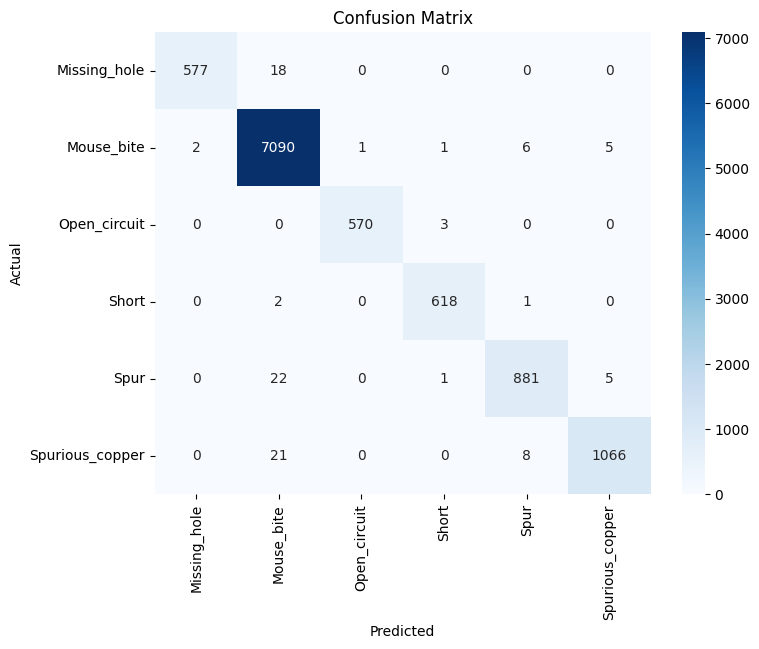

In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
plt.savefig("final_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [32]:
with open("final_report.txt", "w") as f:
    f.write(classification_report(y_true, y_pred, target_names=class_names))